In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Connection statement
conn = sqlite3.connect("../data/Chinook_Sqlite.sqlite")

In [3]:
# Run a SQL query and load the result into a DataFrame
df = pd.read_sql("SELECT * FROM Customer", conn)

print("")
print(df[["CustomerId", "FirstName", "LastName", "Email"]].head())
print(f"\nShape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print("\n", "-"*60, "\n")


   CustomerId  FirstName     LastName                     Email
0           1       Luís    Gonçalves      luisg@embraer.com.br
1           2     Leonie       Köhler     leonekohler@surfeu.de
2           3   François     Tremblay       ftremblay@gmail.com
3           4      Bjørn       Hansen     bjorn.hansen@yahoo.no
4           5  František  Wichterlová  frantisekw@jetbrains.com

Shape: (59, 13)

Columns: ['CustomerId', 'FirstName', 'LastName', 'Company', 'Address', 'City', 'State', 'Country', 'PostalCode', 'Phone', 'Fax', 'Email', 'SupportRepId']

 ------------------------------------------------------------ 



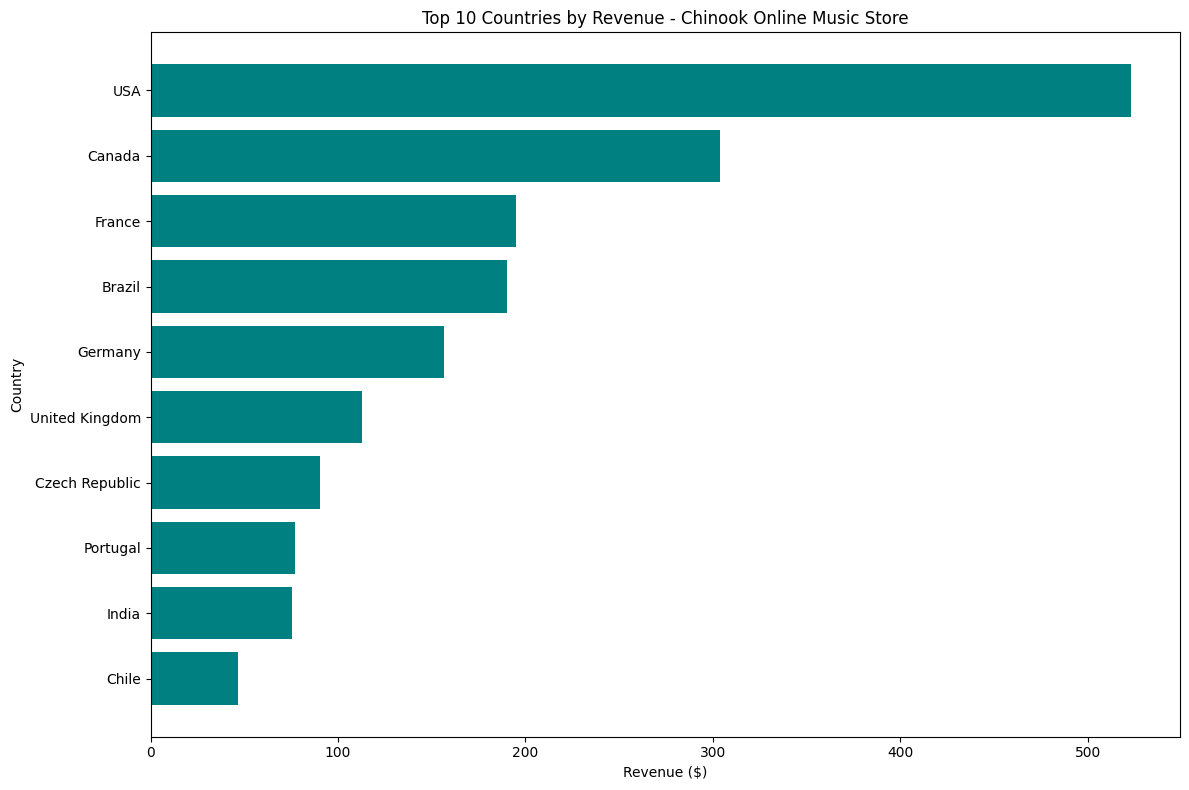

In [4]:
# Which country generates the most revenue?

revenue_df = pd.read_sql("""
    SELECT
        BillingCountry AS Country,
        SUM(Total) AS Revenue,
        AVG(Total) AS AvgRevenue
    FROM Invoice
    GROUP BY Country
    ORDER BY Revenue DESC
    LIMIT 10
""", conn)

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(revenue_df['Country'], revenue_df['Revenue'], color='teal')
ax.set_xlabel('Revenue ($)')
ax.set_ylabel('Country')
ax.set_title('Top 10 Countries by Revenue - Chinook Online Music Store')

ax.invert_yaxis()

plt.tight_layout()
plt.savefig("./Top 10 Countries by Revenue.png", dpi=400, bbox_inches='tight')
plt.show()

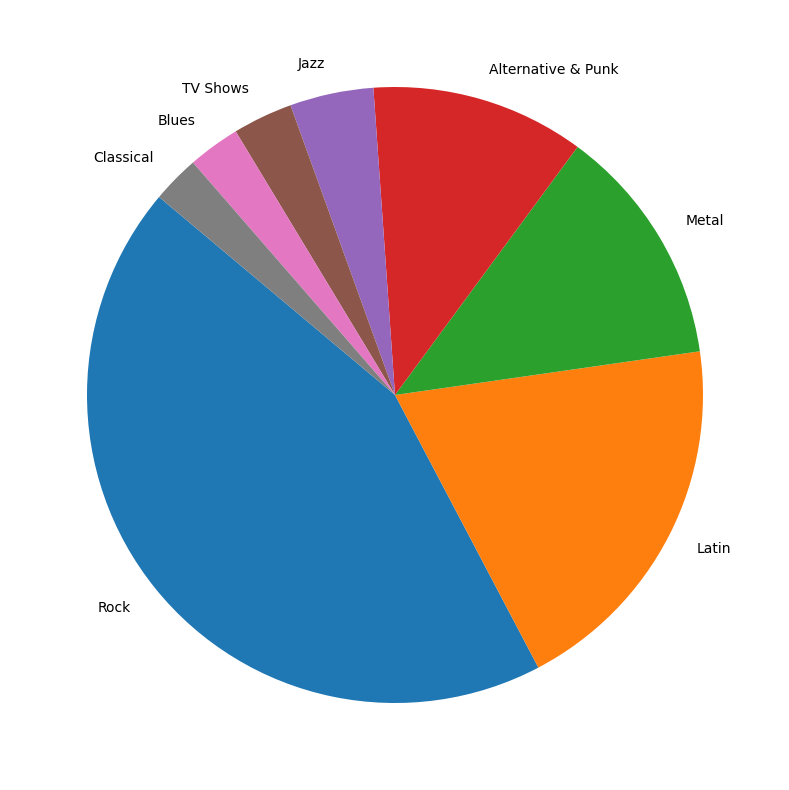

In [5]:
# Show track distribution by genre
# Restless and Wild

query = """
    SELECT g.Name as Genre, COUNT(t.TrackId) AS TrackCount
    FROM Track t
    JOIN Genre g ON t.GenreId = g.GenreId
    GROUP BY g.Name
    Order BY TrackCount DESC
    LIMIT 8
"""

track_dist_df = pd.read_sql(query, conn)

fig, ax = plt.subplots(figsize=(12, 8))
ax.pie(
    track_dist_df['TrackCount'],
    labels=track_dist_df['Genre'],
    startangle=140,
)
plt.tight_layout()
plt.show()